In [16]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


# Carga del Dataset 3.1

In [5]:
path = "dataset/2-EDA-Evolve.csv"
df = pd.read_csv(path)
df.head()

,userid,placeid,datetime,lat,lon,city,category
0,fred-wilson,tocqueville-new-york,2010-10-22T23:44:29,40.736300,-73.992200,New York,NaN
1,fred-wilson,wesleyan-university-usdan-university-center-mi...,2010-10-23T17:00:24,41.556974,-72.657571,Middletown,College & Education:Student Center
2,fred-wilson,javapalooza-middletown,2010-10-23T20:30:45,41.558853,-72.648618,Middletown,Food:Coffee Shop
3,fred-wilson,giorgione-new-york,2010-10-24T00:22:49,40.726144,-74.008348,New York,Food:Italian
4,fred-wilson,the-shala-new-york,2010-10-24T16:01:38,40.733075,-73.991478,New York,Home / Work / Other:Gym / Fitness:Yoga Studio


In [59]:
#df.to_csv("dataset/dataset_TSMC2014_NYC.csv", index=False)

In [6]:
print("Shape" , df.shape) #For rows and columns


Shape (1593872, 7)


In [7]:
df.columns #All the names of the columns in the dataset.

Index(['userid', 'placeid', 'datetime', 'lat', 'lon', 'city', 'category'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593872 entries, 0 to 1593871
Data columns (total 7 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   userid    1561995 non-null  object 
 1   placeid   1482301 non-null  object 
 2   datetime  1291037 non-null  object 
 3   lat       1386669 non-null  float64
 4   lon       1466363 non-null  float64
 5   city      1243221 non-null  object 
 6   category  988201 non-null   object 
dtypes: float64(2), object(5)
memory usage: 85.1+ MB


In [101]:
df.describe() 

,lat,lon
count,1.386669e+06,1.466363e+06
mean,3.781383e+01,-6.955186e+01
std,1.428207e+01,5.897557e+01
min,-7.982024e+01,-1.687500e+02
25%,3.737386e+01,-1.171700e+02
50%,4.067707e+01,-7.704219e+01
75%,4.232670e+01,-7.369864e+01
max,7.362779e+01,1.780716e+02


# Exploración del dataset 3.2

#### Valores nulos

In [90]:
df.isnull()

,userid,placeid,datetime,lat,lon,city,category
0,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1593867,False,False,False,False,False,False,True
1593868,False,True,True,False,False,True,False
1593869,False,False,True,True,False,False,False
1593870,False,False,False,False,False,False,False


In [156]:
df.isnull().sum()

userid       31877
placeid     111571
datetime    302835
lat         207203
lon         127509
city        350651
category    605671
dtype: int64

In [12]:
null_pct=(df.isnull().mean())*100
print(null_pct)


userid       1.999972
placeid      6.999997
datetime    18.999957
lat         12.999977
lon          7.999952
city        21.999947
category    37.999977
dtype: float64


#### Valores duplicados

In [91]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1593867    False
1593868    False
1593869    False
1593870    False
1593871    False
Length: 1593872, dtype: bool

In [74]:
df.duplicated().sum()

np.int64(2)

#### Valores unicos

In [77]:
df['userid'].nunique()

2951

In [144]:
df['category'].nunique()

704

In [145]:
df['lat'].nunique()

205381

In [146]:
df['lon'].nunique()

208483

In [147]:
df['placeid'].nunique()

216890

In [148]:
df['datetime'].head() 

0    2010-10-22T23:44:29
1    2010-10-23T17:00:24
2    2010-10-23T20:30:45
3    2010-10-24T00:22:49
4    2010-10-24T16:01:38
Name: datetime, dtype: object

In [23]:
df_date= df.select_dtypes(include=['datetime'])
df[df_date].head()


,userid,placeid,datetime,lat,lon,city,category
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df.dtypes[df.dtypes.astype(str).str.contains('datetime')]


Series([], dtype: object)

In [92]:
df['city'].nunique()

14171

# Rango de las variables

#### Numeric 

In [113]:
Rnum=df.select_dtypes(include=[np.number]).columns.to_list()
display(df[Rnum].describe().T)
for c in Rnum:
    print(c ,"min" , df[c].min() ,"," "max" , df[c].max())

,count,mean,std,min,25%,50%,75%,max
lat,1386669.0,37.813828,14.282072,-79.820243,37.373856,40.677067,42.326700,73.627789
lon,1466363.0,-69.551856,58.975567,-168.750000,-117.170000,-77.042192,-73.698642,178.071597


lat min -79.8202427478 ,max 73.6277887934
lon min -168.75 ,max 178.071597


#### Object

In [119]:
Robj=df.select_dtypes(include=['object']).columns.to_list()
display(df[Robj].describe().T)

,count,unique,top,freq
userid,1561995,2951,thadd-fiala,6379
placeid,1482301,216890,san-francisco-international-airport-sfo-san-fr...,5491
datetime,1291037,1265698,2010-09-23T16:06:21,4
city,1243221,14171,New York,194862
category,988201,704,Home / Work / Other:Corporate / Office,59763


# 3.3 Limpeieza y Normalizacion

In [181]:
df_clean= df.copy()
df_clean.head()

,userid,placeid,datetime,lat,lon,city,category
0,fred-wilson,tocqueville-new-york,2010-10-22T23:44:29,40.736300,-73.992200,New York,NaN
1,fred-wilson,wesleyan-university-usdan-university-center-mi...,2010-10-23T17:00:24,41.556974,-72.657571,Middletown,College & Education:Student Center
2,fred-wilson,javapalooza-middletown,2010-10-23T20:30:45,41.558853,-72.648618,Middletown,Food:Coffee Shop
3,fred-wilson,giorgione-new-york,2010-10-24T00:22:49,40.726144,-74.008348,New York,Food:Italian
4,fred-wilson,the-shala-new-york,2010-10-24T16:01:38,40.733075,-73.991478,New York,Home / Work / Other:Gym / Fitness:Yoga Studio


#### datetime corrección

##### Date correcion

In [38]:
df_clean['datetime']= pd.to_datetime(df_clean['datetime'] ,errors='coerce') #Converting datetime 
df_clean['datetime'].head()        

0   2010-10-22 23:44:29
1   2010-10-23 17:00:24
2   2010-10-23 20:30:45
3   2010-10-24 00:22:49
4   2010-10-24 16:01:38
Name: datetime, dtype: datetime64[ns]

In [36]:
df_clean['datetime'].dtype

dtype('<M8[ns]')

In [40]:
df_clean['datetime'].isna() #There are null values.

0          False
1          False
2          False
3          False
4          False
           ...  
1593867    False
1593868     True
1593869     True
1593870    False
1593871    False
Name: datetime, Length: 1593872, dtype: bool

In [41]:
df_clean['date']=df_clean['datetime'].dt.date
df_clean['time']=df_clean['datetime'].dt.time

In [42]:
df_clean.head()

,userid,placeid,datetime,lat,lon,city,category,date,time
0,fred-wilson,tocqueville-new-york,2010-10-22 23:44:29,40.736300,-73.992200,New York,NaN,2010-10-22,23:44:29
1,fred-wilson,wesleyan-university-usdan-university-center-mi...,2010-10-23 17:00:24,41.556974,-72.657571,Middletown,College & Education:Student Center,2010-10-23,17:00:24
2,fred-wilson,javapalooza-middletown,2010-10-23 20:30:45,41.558853,-72.648618,Middletown,Food:Coffee Shop,2010-10-23,20:30:45
3,fred-wilson,giorgione-new-york,2010-10-24 00:22:49,40.726144,-74.008348,New York,Food:Italian,2010-10-24,00:22:49
4,fred-wilson,the-shala-new-york,2010-10-24 16:01:38,40.733075,-73.991478,New York,Home / Work / Other:Gym / Fitness:Yoga Studio,2010-10-24,16:01:38


In [46]:
df_clean.drop(columns=['datetime'] , inplace=True) #Delete the datetime column

In [48]:
df_clean.head()

,userid,placeid,lat,lon,city,category,date,time
0,fred-wilson,tocqueville-new-york,40.736300,-73.992200,New York,NaN,2010-10-22,23:44:29
1,fred-wilson,wesleyan-university-usdan-university-center-mi...,41.556974,-72.657571,Middletown,College & Education:Student Center,2010-10-23,17:00:24
2,fred-wilson,javapalooza-middletown,41.558853,-72.648618,Middletown,Food:Coffee Shop,2010-10-23,20:30:45
3,fred-wilson,giorgione-new-york,40.726144,-74.008348,New York,Food:Italian,2010-10-24,00:22:49
4,fred-wilson,the-shala-new-york,40.733075,-73.991478,New York,Home / Work / Other:Gym / Fitness:Yoga Studio,2010-10-24,16:01:38


In [51]:
df_clean['date'].isna().sum()

np.int64(302835)

In [54]:
missing_date_pct=df_clean['date'].isna().sum()/len(df_clean)*100
print(missing_date_pct)

18.999957336599174


In [ ]:
df_clean['date']=df_clean.groupby('userid')['date'].ffill()  #imputing date values using forward filling because it is important for temporal relations.

In [56]:
df_clean['date'].isna().sum()

np.int64(32559)

In [66]:
missing_date_pct=df_clean['date'].isna().sum()/len(df_clean)*100
print(missing_date_pct)


2.042761275685877


In [68]:
missing_time_users=df_clean[df_clean['date'].isna()]
print(missing_time_users[['userid','date']])

        userid date
104        NaN  NaN
132        NaN  NaN
226        NaN  NaN
228        NaN  NaN
287        NaN  NaN
...        ...  ...
1593742    NaN  NaN
1593771    NaN  NaN
1593777    NaN  NaN
1593829    NaN  NaN
1593832    NaN  NaN

[32559 rows x 2 columns]


In [77]:
df_clean['date']=pd.to_datetime(df_clean['date']) #converting object type date to datetime format
df_clean['date'].dtype

dtype('<M8[ns]')

#### Time correccion

In [67]:
df_clean['time'].isna().sum()

np.int64(32559)

In [61]:
missing_time_pct=df_clean['time'].isna().sum()/len(df_clean)*100
print(missing_time_pct)

18.999957336599174


In [62]:
df_clean['time']=df_clean.groupby('userid')['time'].ffill()  #imputing date values using forward filling because it is important for temporal relations.

In [63]:
df_clean['time'].isna().sum()

np.int64(32559)

In [64]:
missing_time_pct=df_clean['time'].isna().sum()/len(df_clean)*100
print(missing_time_pct)

2.042761275685877


In [65]:
missing_time_users=df_clean[df_clean['time'].isna()]
print(missing_time_users[['userid','time']])

        userid time
104        NaN  NaN
132        NaN  NaN
226        NaN  NaN
228        NaN  NaN
287        NaN  NaN
...        ...  ...
1593742    NaN  NaN
1593771    NaN  NaN
1593777    NaN  NaN
1593829    NaN  NaN
1593832    NaN  NaN

[32559 rows x 2 columns]


In [88]:
df_clean['time'] = pd.to_datetime(df_clean['time'], format='%H:%M:%S').dt.time #it will become an object , later we can access month , hour , seconds as we want

C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_17152\2295125799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['time'] = pd.to_datetime(df_clean['time'], format='%H:%M:%S').dt.time


In [90]:
df_clean['time'].dtype

dtype('O')

#### User ID correccion


In [70]:
df_clean['userid'].isna().sum()

np.int64(31877)

In [82]:
df_clean=df_clean.dropna(subset=['userid'])

In [83]:
df_clean['userid'].isna().sum()

np.int64(0)

#### Sorting dataframe based on date and  time 

In [94]:
df_clean=df_clean.sort_values(by=['date','time'], ascending=[True,True])

#### Correccion de placeid

In [98]:
df_clean['placeid'].isna().sum()

np.int64(109286)

In [101]:
df_clean=df_clean.dropna(subset=['placeid'])

In [102]:
df_clean['placeid'].isna().sum()

np.int64(0)

#### Correccion de Latitude y Longitude 

In [104]:
df_clean[['lat','lon']].isna().sum()

lat    188826
lon    116554
dtype: int64

In [111]:
df_clean['lat']= df_clean.groupby('placeid')['lat'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #filling the missing lat values with the same values of placeid.

C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_17152\3319446073.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['lat']= df_clean.groupby('placeid')['lat'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #filling the missing lat values with the same values of placeid.


In [112]:
df_clean['lon']= df_clean.groupby('placeid')['lon'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #NA

C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_17152\1483064232.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['lon']= df_clean.groupby('placeid')['lon'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #NA


In [113]:
df_clean[['lat','lon']].isna().sum()

lat    14338
lon     8488
dtype: int64

In [116]:
df_clean= df_clean.dropna(subset=['lat','lon'])

In [117]:
df_clean[['lat','lon']].isna().sum()

lat    0
lon    0
dtype: int64

#### Correccion de city

In [119]:
df_clean['city'].isna().sum()

np.int64(314591)

In [128]:
df_clean= df_clean.dropna(subset=['city'])

In [129]:
df_clean['city'].isna().sum()

np.int64(0)

#### Correccion de categories

In [134]:
df_clean['category'].isna().sum()


np.int64(424209)

In [135]:
df_clean['category'] = (
    df_clean.groupby('placeid')['category']
    .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
)


C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_17152\1877764260.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_17152\1877764260.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


In [138]:
df_clean['category'].isna().sum()/len(df_clean)*100

np.float64(3.7544520965164363)

In [141]:
df_clean['category'].nunique()

683

##### Reseting index

In [150]:
df_clean.head() #Before reset

,userid,placeid,lat,lon,city,category,date,time
22688,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
22689,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
22690,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
22691,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:06:36
22692,dens,ace-bar-new-york,40.724400,-73.982800,New York,Nightlife:Bar,2003-11-02,23:12:42


In [151]:
df_clean = df_clean.reset_index(drop=True) 


In [152]:
df_clean.head() #After reset

,userid,placeid,lat,lon,city,category,date,time
0,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
1,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
2,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
3,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:06:36
4,dens,ace-bar-new-york,40.724400,-73.982800,New York,Nightlife:Bar,2003-11-02,23:12:42


In [153]:
df_clean = df_clean.drop_duplicates()


In [154]:
df_clean = df_clean.reset_index(drop=True)


In [158]:
df_clean.to_csv('Clean-EDA-Evolve.csv', index=False)


# 3.4 Visualizaciones básicas

In [18]:
df1=pd.read_csv('Clean-EDA-Evolve.csv')
df1.head()

,userid,placeid,lat,lon,city,category,date,time
0,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:04:47
1,dens,bleecker-street-bar-new-york,40.726057,-73.995056,New York,Nightlife:Bar,2003-11-02,06:06:36
2,dens,ace-bar-new-york,40.724400,-73.982800,New York,Nightlife:Bar,2003-11-02,23:12:42
3,dens,ace-bar-new-york,40.724400,-73.982800,New York,Nightlife:Bar,2003-11-02,23:13:44
4,dens,ace-bar-new-york,40.724400,-73.982800,New York,Nightlife:Bar,2003-11-02,23:16:00


#### Visualizacion Basico

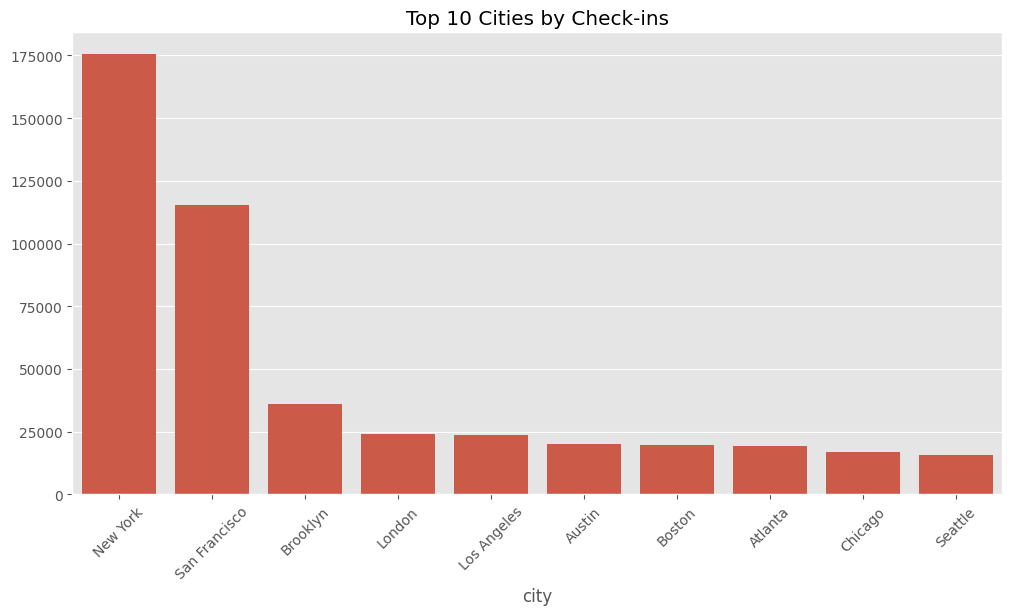

In [8]:
plt.figure(figsize=(12,6))
city_counts = df1['city'].value_counts().head(10)
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.xticks(rotation=45)
plt.title('Top 10 Cities by Check-ins')
plt.show()

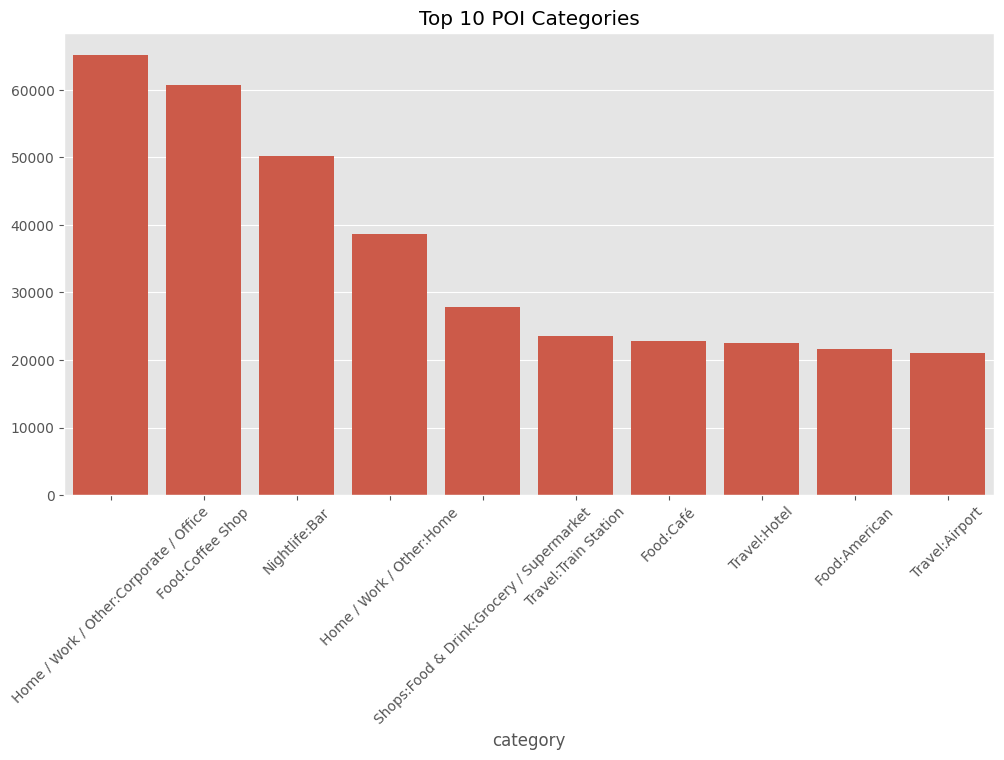

In [7]:
plt.figure(figsize=(12,6))
category_counts = df1['category'].value_counts().head(10)
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=45)
plt.title('Top 10 POI Categories')
plt.show()

#### Temporal Visualizacion

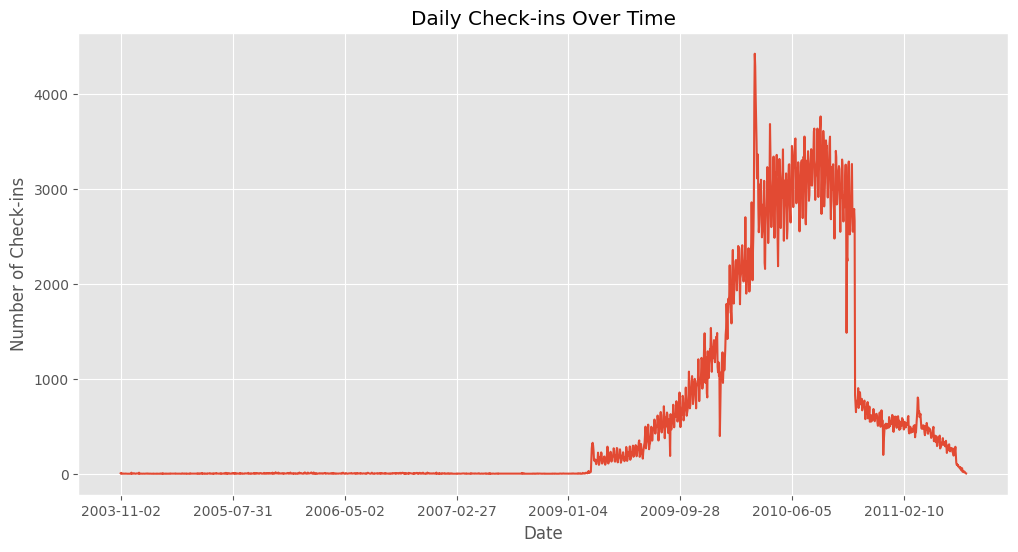

In [184]:
daily_counts = df1.groupby('date').size()
plt.figure(figsize=(12,6))
daily_counts.plot()
plt.title('Daily Check-ins Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Check-ins')
plt.show()

#### Visualizacion Spatial

##### Scatter plot

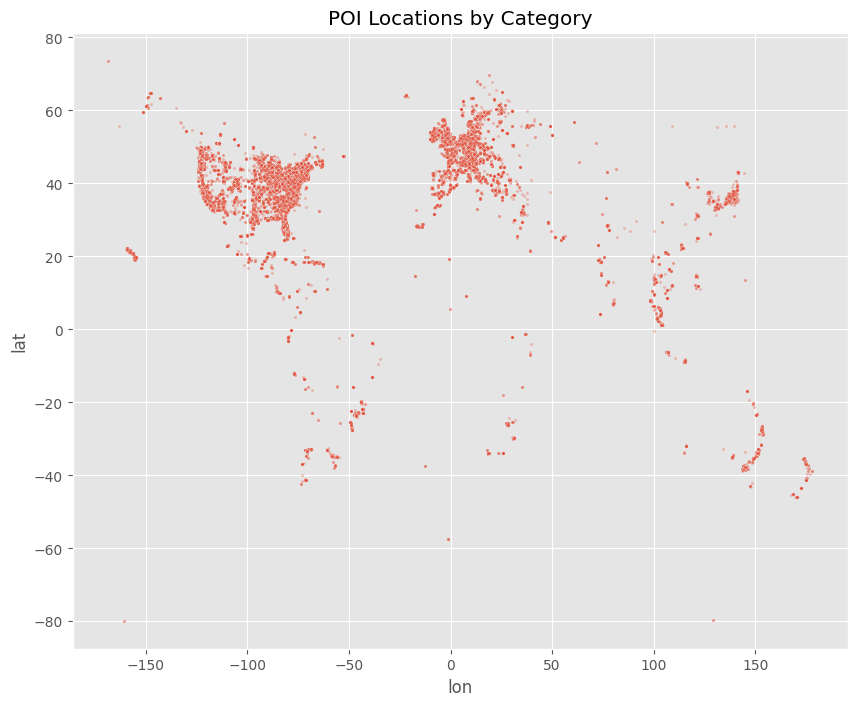

In [188]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='lon', y='lat', data=df1,  s=5, alpha=0.3)
plt.title('POI Locations by Category')
plt.show()

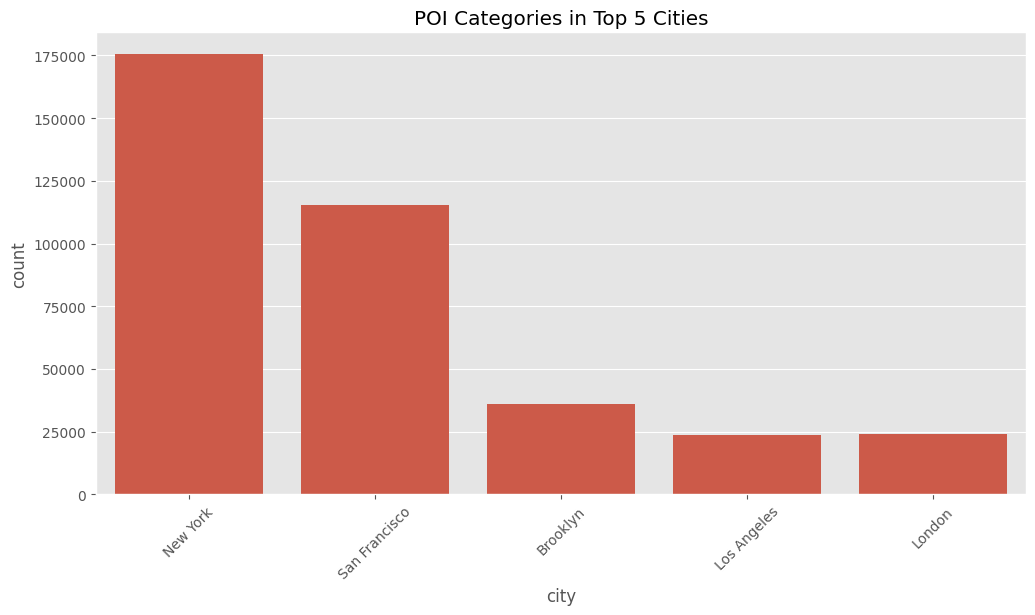

In [9]:
top_cities = df1['city'].value_counts().head(5).index
df_top = df1[df1['city'].isin(top_cities)]
plt.figure(figsize=(12,6))
sns.countplot(data=df_top, x='city')
plt.title('POI Categories in Top 5 Cities')
plt.xticks(rotation=45)
plt.show()

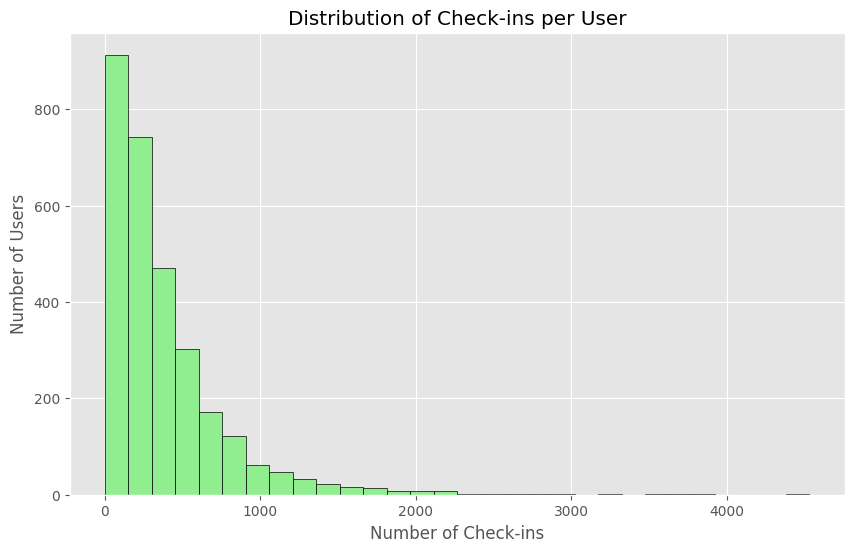

In [11]:
user_counts = df1['userid'].value_counts()
plt.figure(figsize=(10,6))
plt.hist(user_counts, bins=30, color='lightgreen', edgecolor='black')
plt.xlabel('Number of Check-ins')
plt.ylabel('Number of Users')
plt.title('Distribution of Check-ins per User')
plt.show()


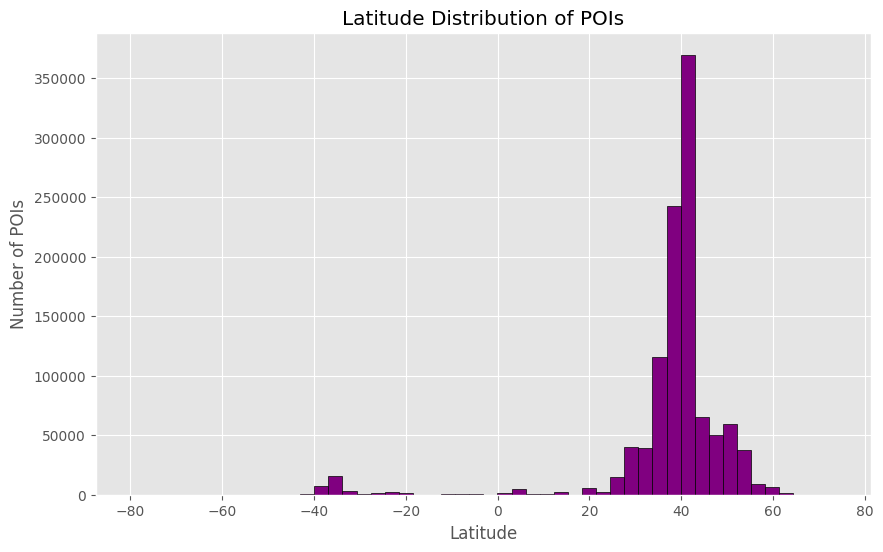

In [15]:
plt.figure(figsize=(10,6))
plt.hist(df1['lat'], bins=50, color='purple', edgecolor='black')
plt.xlabel('Latitude')
plt.ylabel('Number of POIs')
plt.title('Latitude Distribution of POIs')
plt.show()
